# 데이터 점검 결과 요약

- 데이터 크기: 2000행 × 13열
- 결측값 개수: `이탈일`(1668개)
- 전처리 방향
  - `이탈일` 결측은 `이탈여부`가 `N`인 고객에서 발생하는 구조적 결측으로 보고, 무리하게 날짜를 대체하지 않습니다.
  - `가입일`과 `이탈일`은 월별 이탈률 계산을 위해 날짜형으로 변환해야 합니다.
  - `이탈여부`는 이탈률 계산을 위해 0과 1로 표현되는 이탈 지표로 변환해야 합니다.
  - `나이`는 연령대별 교차분석을 위해 10년 단위 연령대 변수로 파생해야 합니다.
  - `고객ID` 중복 여부와 주요 수치형 변수의 이상치를 확인한 뒤, 분석 기준에 맞게 정제해야 합니다.


### 1단계. 데이터 불러오기와 초기 점검

- 지시: 첨부 파일 `customer_churn.csv`를 읽어 데이터프레임 `df`로 생성하고, `df`의 미리보기, 기본 정보, 열별 결측값 개수를 각각 별도의 셀에서 확인하세요. 각 셀 단위로 파이썬 코드를 작성하세요.
- 이유: 분석 전에 데이터 구조, 자료형, 결측 상태를 분리해서 확인해야 이후 전처리 방향을 정확히 정할 수 있기 때문입니다.

In [1]:
# Cell 1
# 이 셀은 pandas 라이브러리를 불러옵니다.
import pandas as pd

In [2]:
# Cell 2
# 이 셀은 customer_churn.csv 파일을 읽어 데이터프레임 df를 생성합니다.
df = pd.read_csv(filepath_or_buffer="customer_churn.csv")

In [3]:
# Cell 3
# 이 셀은 데이터프레임의 처음 5행을 확인합니다.
df.head()

,고객ID,성별,나이,가입채널,요금제,가입일,가입경과월,최근30일_로그인수,월평균사용시간,고객센터문의수,최근3개월_결제실패,이탈여부,이탈일
0,C1000,여,26,오프라인매장,스탠다드,2024-11-07,19,3,9.9,1,1,Y,2026-04-10
1,C1001,남,49,제휴이벤트,베이직,2025-06-07,11,18,9.7,1,0,N,NaN
2,C1002,여,24,오프라인매장,스탠다드,2026-01-16,4,18,28.3,0,0,N,NaN
3,C1003,여,35,지인추천,프리미엄,2024-07-23,22,4,3.8,1,0,Y,2024-12-26
4,C1004,남,31,소셜미디어,베이직,2024-07-14,22,13,6.7,2,0,N,NaN


In [4]:
# Cell 4
# 이 셀은 데이터프레임의 기본 정보를 확인합니다.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   고객ID        2000 non-null   object 
 1   성별          2000 non-null   object 
 2   나이          2000 non-null   int64  
 3   가입채널        2000 non-null   object 
 4   요금제         2000 non-null   object 
 5   가입일         2000 non-null   object 
 6   가입경과월       2000 non-null   int64  
 7   최근30일_로그인수  2000 non-null   int64  
 8   월평균사용시간     2000 non-null   float64
 9   고객센터문의수     2000 non-null   int64  
 10  최근3개월_결제실패  2000 non-null   int64  
 11  이탈여부        2000 non-null   object 
 12  이탈일         332 non-null    object 
dtypes: float64(1), int64(5), object(7)
memory usage: 203.3+ KB


In [5]:
# Cell 5
# 이 셀은 열별 결측값 개수를 확인합니다.
df.isna().sum()

고객ID             0
성별               0
나이               0
가입채널             0
요금제              0
가입일              0
가입경과월            0
최근30일_로그인수       0
월평균사용시간          0
고객센터문의수          0
최근3개월_결제실패       0
이탈여부             0
이탈일           1668
dtype: int64

### 2단계. 핵심 식별자와 이탈 변수 점검

- 지시: `df`에서 `고객ID`의 중복 여부, `이탈여부`의 값 분포, `이탈여부`와 `이탈일`의 논리적 일치 여부를 확인하세요. 각 셀 단위로 파이썬 코드를 작성하세요.
- 이유: 고객 단위 이탈률 분석에서는 고객 식별자 중복과 이탈 라벨의 정합성이 결과를 직접 왜곡할 수 있기 때문입니다.

In [6]:
# Cell 6
# 이 셀은 고객ID의 중복 여부를 확인합니다.
df["고객ID"].duplicated().sum()

0

In [7]:
# Cell 7
# 이 셀은 이탈여부의 값 분포를 확인합니다.
df["이탈여부"].value_counts(dropna=False)

이탈여부
N    1668
Y     332
Name: count, dtype: int64

In [8]:
# Cell 8
# 이 셀은 이탈여부와 이탈일의 논리적 일치 여부를 확인합니다.
# 이탈여부가 'Y'인데 이탈일이 없거나,
# 이탈여부가 'N'인데 이탈일이 있는 경우를 확인합니다.

invalid_rows = df[
    ((df["이탈여부"] == "Y") & (df["이탈일"].isna())) |
    ((df["이탈여부"] == "N") & (df["이탈일"].notna()))
]

invalid_rows

,고객ID,성별,나이,가입채널,요금제,가입일,가입경과월,최근30일_로그인수,월평균사용시간,고객센터문의수,최근3개월_결제실패,이탈여부,이탈일


In [9]:
# Cell 9
# 이 셀은 논리적으로 불일치한 행의 개수를 확인합니다.
len(invalid_rows)

0

### 3단계. 날짜 변수 변환과 기간 점검

- 지시: `df`의 `가입일`과 `이탈일`을 날짜형으로 변환하고, 가입일과 이탈일의 최소일과 최대일 및 이탈일이 가입일보다 빠른 사례가 있는지 확인하세요. 각 셀 단위로 파이썬 코드를 작성하세요.
- 이유: 월별 이탈률은 날짜 기준으로 계산되므로 날짜 변환 오류와 기간 역전 사례를 먼저 제거해야 하기 때문입니다.

In [10]:
# Cell 10
# 이 셀은 가입일과 이탈일을 날짜형으로 변환합니다.
df["가입일"] = pd.to_datetime(arg=df["가입일"])
df["이탈일"] = pd.to_datetime(arg=df["이탈일"])

In [11]:
# Cell 11
# 이 셀은 가입일의 최소일과 최대일을 확인합니다.
df["가입일"].agg(["min", "max"])

min   2023-06-02
max   2026-04-30
Name: 가입일, dtype: datetime64[ns]

In [12]:
# Cell 12
# 이 셀은 이탈일의 최소일과 최대일을 확인합니다.
df["이탈일"].agg(["min", "max"])

min   2024-12-08
max   2026-05-26
Name: 이탈일, dtype: datetime64[ns]

In [13]:
# Cell 13
# 이 셀은 이탈일이 가입일보다 빠른 사례를 확인합니다.
invalid_date_rows = df[df["이탈일"] < df["가입일"]]

invalid_date_rows

,고객ID,성별,나이,가입채널,요금제,가입일,가입경과월,최근30일_로그인수,월평균사용시간,고객센터문의수,최근3개월_결제실패,이탈여부,이탈일


In [14]:
# Cell 14
# 이 셀은 이탈일이 가입일보다 빠른 사례의 개수를 확인합니다.
len(invalid_date_rows)

0

### 4단계. 결측값과 중복값 처리

- 지시: `df`에서 완전 중복 행과 `고객ID` 중복 행을 처리하고, `이탈여부`가 `N`인 고객의 `이탈일` 결측은 유지하며, 그 외 분석에 필요한 열의 결측 처리 결과를 반영한 데이터프레임 `df_clean`을 만드세요.
- 이유: 비이탈 고객의 이탈일 결측은 정상적인 구조이지만 중복과 비정상 결측은 이탈률 계산의 분모와 분자를 왜곡할 수 있기 때문입니다.

In [15]:
# Cell 15
# 이 셀은 완전 중복 행을 제거합니다.
df_clean = df.drop_duplicates()

In [16]:
# Cell 16
# 이 셀은 고객ID 기준 중복 행을 제거합니다.
# 같은 고객ID가 여러 번 있으면 마지막 행을 유지합니다.
df_clean = df_clean.drop_duplicates(subset="고객ID", keep="last")

In [17]:
# Cell 17
# 이 셀은 이탈여부가 N인 고객의 이탈일 결측은 유지하고,
# 이탈여부가 Y인 고객 중 이탈일이 결측인 행은 제거합니다.
df_clean = df_clean[
    ~((df_clean["이탈여부"] == "Y") & (df_clean["이탈일"].isna()))
]

In [18]:
# Cell 18
# 이 셀은 분석에 필요한 열의 결측값이 있는 행을 제거합니다.
# 이탈일은 이탈여부가 N인 고객에게 결측이 정상일 수 있으므로 제외합니다.
analysis_cols = df_clean.columns.drop("이탈일")

df_clean = df_clean.dropna(subset=analysis_cols)

In [19]:
# Cell 19
# 이 셀은 정리된 데이터프레임의 결측 처리 결과를 확인합니다.
df_clean.isna().sum()

고객ID             0
성별               0
나이               0
가입채널             0
요금제              0
가입일              0
가입경과월            0
최근30일_로그인수       0
월평균사용시간          0
고객센터문의수          0
최근3개월_결제실패       0
이탈여부             0
이탈일           1668
dtype: int64

In [20]:
# Cell 20
# 이 셀은 정리된 데이터프레임의 행 개수와 열 개수를 확인합니다.
df_clean.shape

(2000, 13)

### 5단계. 분석용 파생 변수 생성

- 지시: `df_clean`에 `이탈여부`를 바탕으로 1과 0으로 표현되는 `이탈플래그`, `가입일`에서 만든 `가입월`, `이탈일`에서 만든 `이탈월`, `나이`를 10년 단위로 묶은 `연령대` 변수를 추가하세요.
- 이유: 월별 이탈률, 연령대별 이탈률, 가입 채널별 교차분석을 일관된 기준으로 계산하기 위해 필요한 분석 단위를 만들어야 하기 때문입니다.

In [21]:
# Cell 21
# 이 셀은 이탈여부를 1과 0으로 변환한 이탈플래그 변수를 추가합니다.
df_clean["이탈플래그"] = df_clean["이탈여부"].map({"Y": 1, "N": 0})

In [22]:
# Cell 22
# 이 셀은 가입일에서 연-월 단위의 가입월 변수를 추가합니다.
df_clean["가입월"] = df_clean["가입일"].dt.to_period(freq="M")

In [23]:
# Cell 23
# 이 셀은 이탈일에서 연-월 단위의 이탈월 변수를 추가합니다.
df_clean["이탈월"] = df_clean["이탈일"].dt.to_period(freq="M")

In [24]:
# Cell 24
# 이 셀은 나이를 10년 단위로 묶은 연령대 변수를 추가합니다.
df_clean["연령대"] = (df_clean["나이"] // 10 * 10).astype(str) + "대"

In [25]:
# Cell 25
# 이 셀은 추가된 변수의 일부를 확인합니다.
df_clean[["이탈여부", "이탈플래그", "가입일", "가입월", "이탈일", "이탈월", "나이", "연령대"]].head()

,이탈여부,이탈플래그,가입일,가입월,이탈일,이탈월,나이,연령대
0,Y,1,2024-11-07,2024-11,2026-04-10,2026-04,26,20대
1,N,0,2025-06-07,2025-06,NaT,NaT,49,40대
2,N,0,2026-01-16,2026-01,NaT,NaT,24,20대
3,Y,1,2024-07-23,2024-07,2024-12-26,2024-12,35,30대
4,N,0,2024-07-14,2024-07,NaT,NaT,31,30대


### 6단계. 수치형 변수 이상치 점검

- 지시: `df_clean`에서 `나이`, `가입경과월`, `최근30일_로그인수`, `월평균사용시간`, `고객센터문의수`, `최근3개월_결제실패`의 분포와 이상치 후보를 확인하고, 비현실적인 값이 있으면 분석 기준을 정해 처리하세요. 각 셀 단위로 파이썬 코드를 작성하세요.
- 이유: 이탈률이 높은 집단의 특징을 해석할 때 극단값이 평균과 비교 결과를 과도하게 흔들 수 있기 때문입니다.

In [26]:
# Cell 26
# 이 셀은 분포와 이상치를 확인할 수치형 변수 목록을 만듭니다.
num_cols = [
    "나이",
    "가입경과월",
    "최근30일_로그인수",
    "월평균사용시간",
    "고객센터문의수",
    "최근3개월_결제실패"
]

In [27]:
# Cell 27
# 이 셀은 수치형 변수의 기술통계량을 확인합니다.
df_clean[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
나이,2000.0,38.48100,11.395199,19.0,30.000,38.0,46.000,69.0
가입경과월,2000.0,18.30300,10.293793,1.0,9.000,18.0,27.000,36.0
최근30일_로그인수,2000.0,10.55700,4.636324,1.0,8.000,11.0,14.000,26.0
월평균사용시간,2000.0,18.18125,10.366976,1.2,10.375,16.5,23.925,61.4
고객센터문의수,2000.0,0.63700,0.804086,0.0,0.000,0.0,1.000,4.0
최근3개월_결제실패,2000.0,0.29800,0.630392,0.0,0.000,0.0,0.000,3.0


In [28]:
# Cell 28
# 이 셀은 IQR 기준으로 이상치 후보 개수를 확인합니다.
q1 = df_clean[num_cols].quantile(q=0.25)
q3 = df_clean[num_cols].quantile(q=0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outlier_count = ((df_clean[num_cols] < lower) | (df_clean[num_cols] > upper)).sum()

outlier_count

나이              0
가입경과월           0
최근30일_로그인수      5
월평균사용시간        36
고객센터문의수        62
최근3개월_결제실패    433
dtype: int64

In [29]:
# Cell 29
# 이 셀은 IQR 기준 이상치 후보 행을 확인합니다.
outlier_rows = df_clean[
    ((df_clean[num_cols] < lower) | (df_clean[num_cols] > upper)).any(axis=1)
]

outlier_rows[num_cols]

,나이,가입경과월,최근30일_로그인수,월평균사용시간,고객센터문의수,최근3개월_결제실패
0,26,19,3,9.9,1,1
8,35,9,14,13.0,0,1
20,47,16,22,33.1,0,1
21,19,5,3,2.6,1,3
27,38,17,16,56.0,0,1
...,...,...,...,...,...,...
1981,52,34,16,23.1,0,1
1982,44,4,19,27.3,0,1
1983,39,32,13,9.7,0,1
1990,37,35,16,12.6,1,1


In [30]:
# Cell 30
# 이 셀은 분석 기준상 비현실적인 값이 있는 행을 확인합니다.
# 기준:
# 나이는 0세 이상 100세 이하
# 가입경과월은 0 이상
# 로그인수, 사용시간, 문의수, 결제실패 횟수는 0 이상

unrealistic_rows = df_clean[
    (df_clean["나이"] < 0) |
    (df_clean["나이"] > 100) |
    (df_clean["가입경과월"] < 0) |
    (df_clean["최근30일_로그인수"] < 0) |
    (df_clean["월평균사용시간"] < 0) |
    (df_clean["고객센터문의수"] < 0) |
    (df_clean["최근3개월_결제실패"] < 0)
]

unrealistic_rows[num_cols]

,나이,가입경과월,최근30일_로그인수,월평균사용시간,고객센터문의수,최근3개월_결제실패


In [31]:
# Cell 31
# 이 셀은 비현실적인 값이 있는 행을 제거하여 df_clean에 반영합니다.
df_clean = df_clean.drop(index=unrealistic_rows.index)

In [32]:
# Cell 32
# 이 셀은 처리 후 수치형 변수의 기술통계량을 다시 확인합니다.
df_clean[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
나이,2000.0,38.48100,11.395199,19.0,30.000,38.0,46.000,69.0
가입경과월,2000.0,18.30300,10.293793,1.0,9.000,18.0,27.000,36.0
최근30일_로그인수,2000.0,10.55700,4.636324,1.0,8.000,11.0,14.000,26.0
월평균사용시간,2000.0,18.18125,10.366976,1.2,10.375,16.5,23.925,61.4
고객센터문의수,2000.0,0.63700,0.804086,0.0,0.000,0.0,1.000,4.0
최근3개월_결제실패,2000.0,0.29800,0.630392,0.0,0.000,0.0,0.000,3.0


### 7단계. 전처리 완료 데이터 저장

- 지시: `df_clean`을 원본 파일과 같은 CSV 형식의 `customer_churn_preprocessed.csv` 파일로 저장하세요.
- 이유: 후속 시각화와 통계 분석에서 동일한 정제 데이터를 재사용해야 분석 결과의 재현성을 확보할 수 있기 때문입니다.

In [33]:
# Cell 33
# 이 셀은 전처리된 데이터프레임을 CSV 파일로 저장합니다.
# 원본과 동일하게 CSV 형식으로 저장하며 인덱스는 제외합니다.
df_clean.to_csv(
    path_or_buf="customer_churn_preprocessed.csv",
    index=False
)

In [34]:
# Cell 34
# 이 셀은 저장된 파일이 정상적으로 생성되었는지 확인합니다.
import os

os.path.exists("customer_churn_preprocessed.csv")

True

### 8단계. 전처리 완료 파일 재불러오기와 통계 분석용 인코딩

- 지시: `customer_churn_preprocessed.csv` 파일을 읽어 데이터프레임 `churn_df`로 생성하고, 명목형 범주인 `연령대`와 `가입채널`은 원-핫 인코딩한 별도 분석용 데이터프레임을 만들며, 교차표 계산에는 원래 범주 값을 유지하세요.
- 이유: 전처리 이후 분석은 저장된 정제 파일에서 시작해야 하며, 범주형 변수는 통계 검정이나 추가 모델링에 사용할 수 있도록 분석 국면 초입에서 인코딩해야 하기 때문입니다.

In [35]:
# Cell 35
# 이 셀은 전처리된 CSV 파일을 읽어 데이터프레임 churn_df를 생성합니다.
import pandas as pd

In [36]:
# Cell 36
# 이 셀은 customer_churn_preprocessed.csv 파일을 읽습니다.
churn_df = pd.read_csv(filepath_or_buffer="customer_churn_preprocessed.csv")

In [37]:
# Cell 37
# 이 셀은 교차표 계산에 사용할 원래 범주 값을 유지한 데이터프레임을 만듭니다.
churn_cross_df = churn_df.copy()

In [38]:
# Cell 38
# 이 셀은 분석용 데이터프레임에서 연령대와 가입채널을 원-핫 인코딩합니다.
churn_analysis_df = pd.get_dummies(
    data=churn_df,
    columns=["연령대", "가입채널"],
    drop_first=False
)

In [39]:
# Cell 39
# 이 셀은 원-핫 인코딩된 분석용 데이터프레임의 일부를 확인합니다.
churn_analysis_df.head()

,고객ID,성별,나이,요금제,가입일,가입경과월,최근30일_로그인수,월평균사용시간,고객센터문의수,최근3개월_결제실패,...,연령대_20대,연령대_30대,연령대_40대,연령대_50대,연령대_60대,가입채널_검색광고,가입채널_소셜미디어,가입채널_오프라인매장,가입채널_제휴이벤트,가입채널_지인추천
0,C1000,여,26,스탠다드,2024-11-07,19,3,9.9,1,1,...,True,False,False,False,False,False,False,True,False,False
1,C1001,남,49,베이직,2025-06-07,11,18,9.7,1,0,...,False,False,True,False,False,False,False,False,True,False
2,C1002,여,24,스탠다드,2026-01-16,4,18,28.3,0,0,...,True,False,False,False,False,False,False,True,False,False
3,C1003,여,35,프리미엄,2024-07-23,22,4,3.8,1,0,...,False,True,False,False,False,False,False,False,False,True
4,C1004,남,31,베이직,2024-07-14,22,13,6.7,2,0,...,False,True,False,False,False,False,True,False,False,False


In [40]:
# Cell 40
# 이 셀은 교차표용 데이터프레임에 원래 범주 값이 유지되었는지 확인합니다.
churn_cross_df[["연령대", "가입채널"]].head()

,연령대,가입채널
0,20대,오프라인매장
1,40대,제휴이벤트
2,20대,오프라인매장
3,30대,지인추천
4,30대,소셜미디어


### 9단계. 월별 고객 이탈률 계산

- 지시: `churn_df`에서 각 월의 이탈 고객 수를 분자로, 해당 월 초 기준 가입되어 있고 아직 이탈하지 않은 활성 고객 수를 분모로 하여 월별 고객 이탈률 표를 계산하세요.
- 이유: 월별 이탈률은 단순 전체 고객 대비 이탈 수가 아니라 해당 월에 이탈 가능 상태였던 고객을 기준으로 계산해야 하기 때문입니다.

In [41]:
# Cell 41
# 이 셀은 가입일과 이탈일을 날짜형으로 변환합니다.
churn_df["가입일"] = pd.to_datetime(arg=churn_df["가입일"])
churn_df["이탈일"] = pd.to_datetime(arg=churn_df["이탈일"])

In [42]:
# Cell 42
# 이 셀은 월별 이탈률 계산에 사용할 월 목록을 생성합니다.
month_index = pd.period_range(
    start=churn_df["가입일"].min().to_period(freq="M"),
    end=churn_df["이탈일"].max().to_period(freq="M"),
    freq="M"
)

In [43]:
# Cell 43
# 이 셀은 각 월의 이탈 고객 수, 월초 활성 고객 수, 월별 이탈률을 계산합니다.
monthly_churn_rate = pd.DataFrame(index=month_index)

monthly_churn_rate["이탈고객수"] = [
    churn_df["이탈일"].dt.to_period(freq="M").eq(other=month).sum()
    for month in month_index
]

monthly_churn_rate["월초활성고객수"] = [
    (
        (churn_df["가입일"] < month.to_timestamp(how="start")) &
        (
            churn_df["이탈일"].isna() |
            (churn_df["이탈일"] >= month.to_timestamp(how="start"))
        )
    ).sum()
    for month in month_index
]

monthly_churn_rate["월별이탈률"] = (
    monthly_churn_rate["이탈고객수"] /
    monthly_churn_rate["월초활성고객수"]
)

monthly_churn_rate

,이탈고객수,월초활성고객수,월별이탈률
2023-06,0,0,NaN
2023-07,0,69,0.000000
2023-08,0,122,0.000000
2023-09,0,176,0.000000
2023-10,0,227,0.000000
2023-11,0,283,0.000000
2023-12,0,338,0.000000
2024-01,0,402,0.000000
2024-02,0,463,0.000000
2024-03,0,519,0.000000


In [44]:
# Cell 44
# 이 셀은 월별 이탈률 표의 인덱스를 열로 바꾸고 보기 좋게 정리합니다.
monthly_churn_rate = monthly_churn_rate.reset_index(names="기준월")

monthly_churn_rate

,기준월,이탈고객수,월초활성고객수,월별이탈률
0,2023-06,0,0,NaN
1,2023-07,0,69,0.000000
2,2023-08,0,122,0.000000
3,2023-09,0,176,0.000000
4,2023-10,0,227,0.000000
5,2023-11,0,283,0.000000
6,2023-12,0,338,0.000000
7,2024-01,0,402,0.000000
8,2024-02,0,463,0.000000
9,2024-03,0,519,0.000000


### 10단계. 월별 고객 이탈률 시각화

- 지시: 월별 고객 이탈률 표를 이용해 월별 이탈률 추이를 선 그래프로 시각화하고, 월별 이탈 고객 수를 함께 확인할 수 있는 보조 표를 출력하세요. 각 셀 단위로 파이썬 코드를 작성하세요.
- 이유: 시간 흐름에 따른 이탈률 변화와 특정 월의 급증 여부를 함께 확인해야 이탈 위험 시점을 해석할 수 있기 때문입니다.

In [45]:
# Cell 45
# 이 셀은 그래프 작성에 필요한 라이브러리를 불러오고 한글 폰트를 설정합니다.
import platform
import matplotlib.pyplot as plt

system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

In [46]:
# Cell 46
# 이 셀은 기준월을 문자열로 변환하여 그래프의 x축 값으로 사용합니다.
monthly_churn_rate["기준월"] = monthly_churn_rate["기준월"].astype(str)

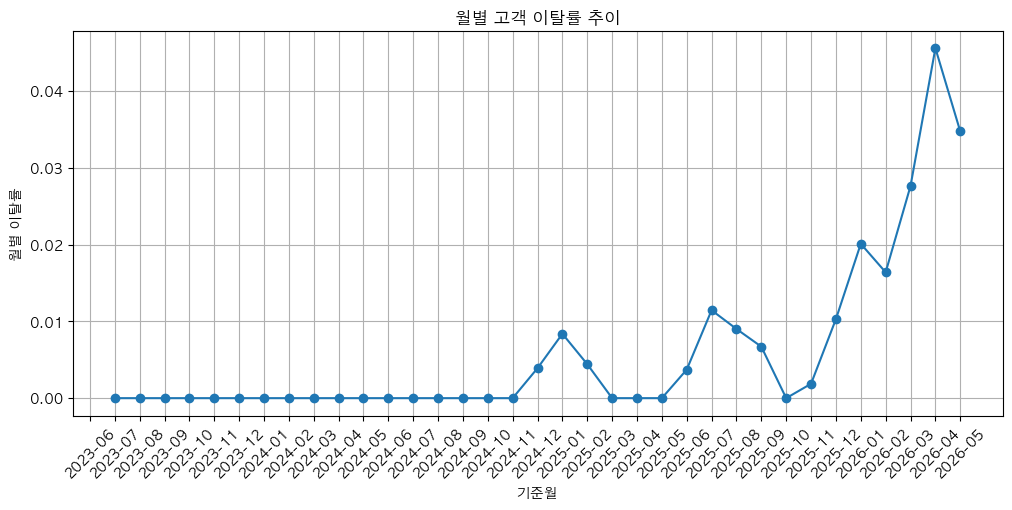

In [47]:
# Cell 47
# 이 셀은 월별 이탈률 추이를 선 그래프로 시각화합니다.
plt.figure(figsize=(12, 5))
plt.plot(
    monthly_churn_rate["기준월"],
    monthly_churn_rate["월별이탈률"],
    marker="o"
)
plt.title(label="월별 고객 이탈률 추이")
plt.xlabel(xlabel="기준월")
plt.ylabel(ylabel="월별 이탈률")
plt.xticks(rotation=45)
plt.grid(visible=True)
plt.show()

In [48]:
# Cell 48
# 이 셀은 월별 이탈 고객 수를 함께 확인할 수 있는 보조 표를 만듭니다.
monthly_churn_summary = monthly_churn_rate[
    ["기준월", "이탈고객수", "월초활성고객수", "월별이탈률"]
].copy()

monthly_churn_summary

,기준월,이탈고객수,월초활성고객수,월별이탈률
0,2023-06,0,0,NaN
1,2023-07,0,69,0.000000
2,2023-08,0,122,0.000000
3,2023-09,0,176,0.000000
4,2023-10,0,227,0.000000
5,2023-11,0,283,0.000000
6,2023-12,0,338,0.000000
7,2024-01,0,402,0.000000
8,2024-02,0,463,0.000000
9,2024-03,0,519,0.000000


### 11단계. 연령대와 가입 채널별 교차 이탈률 계산

- 지시: `churn_df`에서 `연령대`와 `가입채널` 조합별 전체 고객 수, 이탈 고객 수, 이탈률을 계산하고, 고객 수가 너무 적은 조합은 별도로 표시한 교차분석 표를 만드세요.
- 이유: 교차분석에서는 이탈률뿐 아니라 표본 수를 함께 봐야 우연히 높게 나온 소규모 집단을 과대해석하지 않을 수 있기 때문입니다.

In [49]:
# Cell 49
# 이 셀은 연령대와 가입채널 조합별 전체 고객 수와 이탈 고객 수를 계산합니다.
churn_cross_table = churn_df.groupby(
    by=["연령대", "가입채널"],
    as_index=False
).agg(
    전체고객수=("고객ID", "count"),
    이탈고객수=("이탈플래그", "sum")
)

In [50]:
# Cell 50
# 이 셀은 연령대와 가입채널 조합별 이탈률을 계산합니다.
churn_cross_table["이탈률"] = (
    churn_cross_table["이탈고객수"] /
    churn_cross_table["전체고객수"]
)

In [51]:
# Cell 51
# 이 셀은 고객 수가 너무 적은 조합을 표시합니다.
# 기준: 전체고객수가 30명 미만이면 표본부족으로 표시합니다.
min_customer_count = 30

churn_cross_table["표본상태"] = churn_cross_table["전체고객수"].lt(
    other=min_customer_count
).map({True: "표본부족", False: "분석가능"})

In [52]:
# Cell 52
# 이 셀은 교차분석 표를 이탈률 기준 내림차순으로 정렬합니다.
churn_cross_table = churn_cross_table.sort_values(
    by=["표본상태", "이탈률"],
    ascending=[True, False]
)

churn_cross_table

,연령대,가입채널,전체고객수,이탈고객수,이탈률,표본상태
8,20대,제휴이벤트,71,29,0.408451,분석가능
18,40대,제휴이벤트,116,33,0.284483,분석가능
7,20대,오프라인매장,55,14,0.254545,분석가능
23,50대,제휴이벤트,47,11,0.234043,분석가능
13,30대,제휴이벤트,102,22,0.215686,분석가능
0,10대,검색광고,35,7,0.200000,분석가능
17,40대,오프라인매장,77,15,0.194805,분석가능
6,20대,소셜미디어,85,16,0.188235,분석가능
5,20대,검색광고,77,13,0.168831,분석가능
15,40대,검색광고,155,25,0.161290,분석가능


### 12단계. 교차 이탈률 시각화

- 지시: 연령대와 가입 채널 조합별 이탈률을 한눈에 비교할 수 있도록 교차 이탈률 표를 시각화하고, 이탈률이 높은 상위 조합을 별도 막대그래프로 보여주세요. 각 셀 단위로 파이썬 코드를 작성하세요.
- 이유: 시각화는 연령대와 가입 채널이 결합될 때 나타나는 고위험 집단을 빠르게 찾는 데 효과적이기 때문입니다.

In [53]:
# Cell 53
# 이 셀은 교차 이탈률 표를 만듭니다.
churn_rate_pivot = churn_cross_table.pivot(
    index="연령대",
    columns="가입채널",
    values="이탈률"
)

churn_rate_pivot

가입채널,검색광고,소셜미디어,오프라인매장,제휴이벤트,지인추천
연령대,,,,,
10대,0.200000,0.333333,0.083333,0.384615,0.166667
20대,0.168831,0.188235,0.254545,0.408451,0.120690
30대,0.090361,0.123188,0.152381,0.215686,0.092593
40대,0.161290,0.111111,0.194805,0.284483,0.137255
50대,0.121622,0.129630,0.093023,0.234043,0.063830
60대,0.105263,0.125000,0.090909,0.153846,0.000000


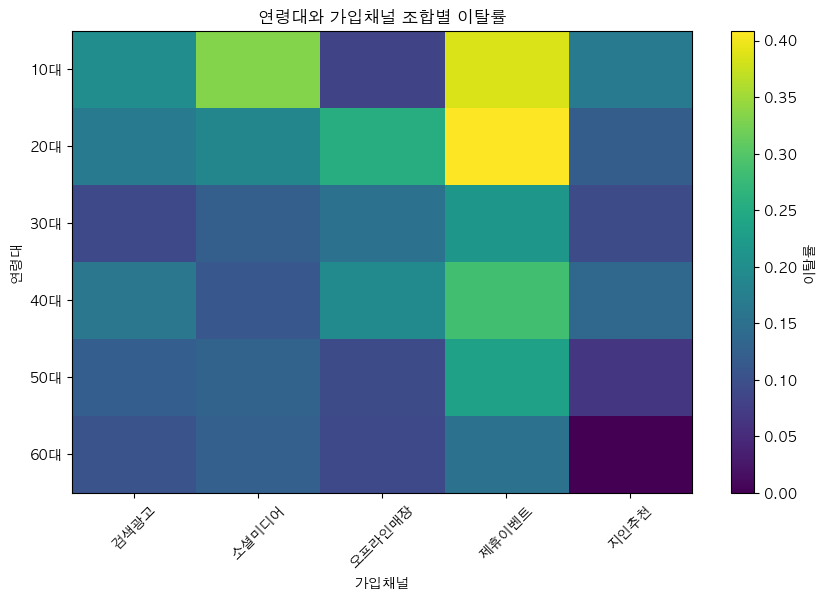

In [54]:
# Cell 54
# 이 셀은 교차 이탈률 표를 히트맵으로 시각화합니다.
plt.figure(figsize=(10, 6))
plt.imshow(churn_rate_pivot, aspect="auto")

plt.title(label="연령대와 가입채널 조합별 이탈률")
plt.xlabel(xlabel="가입채널")
plt.ylabel(ylabel="연령대")

plt.xticks(
    ticks=range(len(churn_rate_pivot.columns)),
    labels=churn_rate_pivot.columns,
    rotation=45
)
plt.yticks(
    ticks=range(len(churn_rate_pivot.index)),
    labels=churn_rate_pivot.index
)

plt.colorbar(label="이탈률")
plt.show()

In [55]:
# Cell 55
# 이 셀은 표본부족 조합을 제외하고 이탈률이 높은 상위 조합을 만듭니다.
top_churn_groups = churn_cross_table[
    churn_cross_table["표본상태"] == "분석가능"
].copy()

top_churn_groups["조합"] = (
    top_churn_groups["연령대"].astype(str) + " / " +
    top_churn_groups["가입채널"].astype(str)
)

top_churn_groups = top_churn_groups.sort_values(
    by="이탈률",
    ascending=False
).head(10)

top_churn_groups

,연령대,가입채널,전체고객수,이탈고객수,이탈률,표본상태,조합
8,20대,제휴이벤트,71,29,0.408451,분석가능,20대 / 제휴이벤트
18,40대,제휴이벤트,116,33,0.284483,분석가능,40대 / 제휴이벤트
7,20대,오프라인매장,55,14,0.254545,분석가능,20대 / 오프라인매장
23,50대,제휴이벤트,47,11,0.234043,분석가능,50대 / 제휴이벤트
13,30대,제휴이벤트,102,22,0.215686,분석가능,30대 / 제휴이벤트
0,10대,검색광고,35,7,0.200000,분석가능,10대 / 검색광고
17,40대,오프라인매장,77,15,0.194805,분석가능,40대 / 오프라인매장
6,20대,소셜미디어,85,16,0.188235,분석가능,20대 / 소셜미디어
5,20대,검색광고,77,13,0.168831,분석가능,20대 / 검색광고
15,40대,검색광고,155,25,0.161290,분석가능,40대 / 검색광고


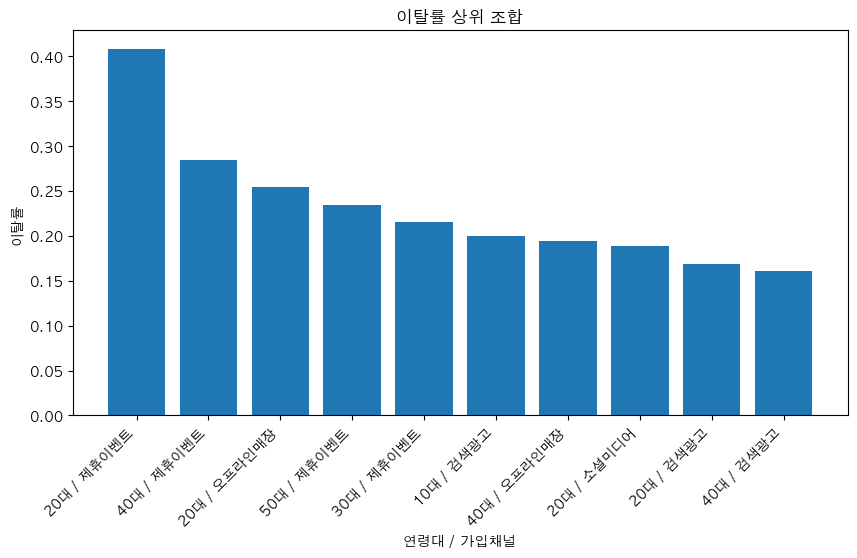

In [56]:
# Cell 56
# 이 셀은 이탈률이 높은 상위 조합을 막대그래프로 시각화합니다.
plt.figure(figsize=(10, 5))
plt.bar(
    x=top_churn_groups["조합"],
    height=top_churn_groups["이탈률"]
)

plt.title(label="이탈률 상위 조합")
plt.xlabel(xlabel="연령대 / 가입채널")
plt.ylabel(ylabel="이탈률")
plt.xticks(rotation=45, ha="right")
plt.show()

### 13단계. 이탈률 최고 집단 식별

- 지시: `churn_df`에서 표본 수 기준을 충족하는 연령대와 가입 채널 조합 중 이탈률이 가장 높은 집단을 찾고, 해당 집단의 고객 수, 이탈 고객 수, 이탈률을 표로 정리하세요.
- 이유: 최고 이탈률 집단을 찾을 때는 이탈률과 표본 수를 함께 제시해야 실행 가능한 타깃 집단인지 판단할 수 있기 때문입니다.

In [57]:
# Cell 57
# 이 셀은 표본 수 기준을 충족하는 조합만 추출합니다.
valid_churn_groups = churn_cross_table[
    churn_cross_table["표본상태"] == "분석가능"
].copy()

In [58]:
# Cell 58
# 이 셀은 표본 수 기준을 충족하는 조합 중 이탈률이 가장 높은 집단을 찾습니다.
top_churn_group_summary = valid_churn_groups.sort_values(
    by="이탈률",
    ascending=False
).head(1)

In [59]:
# Cell 59
# 이 셀은 이탈률이 가장 높은 집단의 고객 수, 이탈 고객 수, 이탈률을 표로 정리합니다.
top_churn_group_summary[
    ["연령대", "가입채널", "전체고객수", "이탈고객수", "이탈률"]
]

,연령대,가입채널,전체고객수,이탈고객수,이탈률
8,20대,제휴이벤트,71,29,0.408451


### 14단계. 최고 이탈률 집단의 특징 비교

- 지시: 이탈률이 가장 높은 집단과 전체 고객을 비교하여 `성별`, `요금제`, `가입경과월`, `최근30일_로그인수`, `월평균사용시간`, `고객센터문의수`, `최근3개월_결제실패`의 차이를 요약 표로 계산하세요.
- 이유: 고위험 집단의 특징은 인구통계 정보뿐 아니라 사용 행동과 결제 문제를 함께 비교해야 원인 가설을 세울 수 있기 때문입니다.

In [60]:
# Cell 60
# 이 셀은 이탈률이 가장 높은 집단의 연령대와 가입채널 값을 가져옵니다.
top_age_group = top_churn_group_summary["연령대"].iloc[0]
top_channel = top_churn_group_summary["가입채널"].iloc[0]

In [61]:
# Cell 61
# 이 셀은 이탈률이 가장 높은 집단에 해당하는 고객만 추출합니다.
top_group_df = churn_df[
    (churn_df["연령대"] == top_age_group) &
    (churn_df["가입채널"] == top_channel)
].copy()

In [62]:
# Cell 62
# 이 셀은 비교할 범주형 변수의 분포를 전체 고객과 상위 이탈 집단별로 계산합니다.
gender_plan_summary = pd.concat(
    objs=[
        churn_df[["성별", "요금제"]].astype(str).agg(lambda x: x.value_counts(normalize=True).idxmax()),
        top_group_df[["성별", "요금제"]].astype(str).agg(lambda x: x.value_counts(normalize=True).idxmax())
    ],
    axis=1
)

gender_plan_summary.columns = ["전체고객_최빈범주", "상위이탈집단_최빈범주"]

gender_plan_summary

,전체고객_최빈범주,상위이탈집단_최빈범주
성별,남,여
요금제,베이직,베이직


In [63]:
# Cell 63
# 이 셀은 비교할 수치형 변수의 평균을 전체 고객과 상위 이탈 집단별로 계산합니다.
compare_num_cols = [
    "가입경과월",
    "최근30일_로그인수",
    "월평균사용시간",
    "고객센터문의수",
    "최근3개월_결제실패"
]

numeric_compare_summary = pd.DataFrame({
    "전체고객_평균": churn_df[compare_num_cols].mean(),
    "상위이탈집단_평균": top_group_df[compare_num_cols].mean()
})

numeric_compare_summary["차이"] = (
    numeric_compare_summary["상위이탈집단_평균"] -
    numeric_compare_summary["전체고객_평균"]
)

numeric_compare_summary

,전체고객_평균,상위이탈집단_평균,차이
가입경과월,18.30300,19.619718,1.316718
최근30일_로그인수,10.55700,8.436620,-2.120380
월평균사용시간,18.18125,14.353521,-3.827729
고객센터문의수,0.63700,0.676056,0.039056
최근3개월_결제실패,0.29800,0.436620,0.138620


In [64]:
# Cell 64
# 이 셀은 성별과 요금제의 범주별 비율 차이를 계산합니다.
categorical_compare_summary = pd.concat(
    objs=[
        pd.crosstab(
            index=churn_df["성별"],
            columns="전체고객_비율",
            normalize="columns"
        ),
        pd.crosstab(
            index=top_group_df["성별"],
            columns="상위이탈집단_비율",
            normalize="columns"
        )
    ],
    axis=1
).fillna(value=0)

categorical_compare_summary["차이"] = (
    categorical_compare_summary["상위이탈집단_비율"] -
    categorical_compare_summary["전체고객_비율"]
)

categorical_compare_summary

col_0,전체고객_비율,상위이탈집단_비율,차이
성별,,,
남,0.504,0.464789,-0.039211
여,0.496,0.535211,0.039211


In [65]:
# Cell 65
# 이 셀은 요금제의 범주별 비율 차이를 계산합니다.
plan_compare_summary = pd.concat(
    objs=[
        pd.crosstab(
            index=churn_df["요금제"],
            columns="전체고객_비율",
            normalize="columns"
        ),
        pd.crosstab(
            index=top_group_df["요금제"],
            columns="상위이탈집단_비율",
            normalize="columns"
        )
    ],
    axis=1
).fillna(value=0)

plan_compare_summary["차이"] = (
    plan_compare_summary["상위이탈집단_비율"] -
    plan_compare_summary["전체고객_비율"]
)

plan_compare_summary

col_0,전체고객_비율,상위이탈집단_비율,차이
요금제,,,
베이직,0.4510,0.507042,0.056042
스탠다드,0.3525,0.323944,-0.028556
프리미엄,0.1965,0.169014,-0.027486


### 15단계. 교차분석 결과 저장

- 지시: 월별 이탈률 표, 연령대와 가입 채널별 교차 이탈률 표, 최고 이탈률 집단 특징 비교 표를 각각 CSV 파일로 저장하세요.
- 이유: 계산 결과를 파일로 남겨야 보고서 작성과 추가 분석에서 동일한 산출물을 재사용할 수 있기 때문입니다.